In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset, DataLoader

import kagglehub

import time
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

c:\Users\Mike\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


In [2]:
#adjustable for experiment

from Classifiers import ControlClassifier, EncodedClassifier

num_epochs   = 50
lr           = 1e-4 #same lr for both to reduce confounding variables
batch_size   = 128
num_classes  = 8    
latent_dim   = 256
weight_decay = 1e-4 #to reduce overfitting

criterion = nn.CrossEntropyLoss()

control_classifier = ControlClassifier(num_classes).to(device)
encoded_classifier = EncodedClassifier(latent_dim, num_classes).to(device)


control_optimizer = optim.Adam(control_classifier.parameters(), lr=lr, weight_decay=weight_decay)
encoded_optimizer = optim.Adam(encoded_classifier.parameters(), lr=lr, weight_decay=weight_decay)

In [3]:
#importing images
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_dataset = kagglehub.dataset_download("obulisainaren/retinal-oct-c8")
full_dataset += '/RetinalOCT_Dataset/RetinalOCT_Dataset' 
train_dataset = ImageFolder(
    root=full_dataset+'/train',
    transform=transform
)

train_loader = DataLoader(
   dataset=train_dataset,
   batch_size=batch_size,
   shuffle=True,
   #increases compute speed
   num_workers=8,
   pin_memory=True
)

val_dataset = ImageFolder(
    root= full_dataset+'/val',
    transform=transform
)

#val
val_loader = DataLoader(
   dataset=val_dataset,
   batch_size=batch_size,
   shuffle=False,
   #increases compute speed
   num_workers=8,
   pin_memory=True
)

#test
test_dataset = ImageFolder(
    root= full_dataset+'/test',
    transform=transform
)

test_loader = DataLoader(
   dataset=test_dataset,
   batch_size=batch_size,
   shuffle=False,
   #increases compute speed
   num_workers=8,
   pin_memory=True
)

In [4]:
#training control
start_time = time.perf_counter()

control_train_losses = []
control_val_losses = []

for epoch in range(num_epochs):
    control_classifier.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        output = control_classifier(images)
        loss = criterion(output, labels)

        control_optimizer.zero_grad()
        loss.backward()
        control_optimizer.step()

        total_loss += loss.item()

        predicted = output.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total
    end_time = time.perf_counter()
    control_train_losses.append(epoch_train_loss)

    #val
    control_classifier.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            output = control_classifier(images)
            loss = criterion(output, labels)
            
            val_loss += loss.item()

            predicted = output.argmax(dim=1)

            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_accuracy = 100 * val_correct / val_total
    control_val_losses.append(epoch_val_loss)


    print(
        f"Epoch {epoch+1}: "
        f"Training: Loss={epoch_train_loss:.4f}, "
        f"Accuracy={accuracy:.2f}%      "
        f"Validation: Loss={epoch_val_loss:.4f}, "
        f"Val Acc={epoch_val_accuracy:.2f}%"
    )
    


control_accuracy = epoch_val_accuracy
control_train_time = end_time - start_time

print(
    f"Results: Accuracy={control_accuracy:.2f}% "
    f"Training Duration={control_train_time:.6f} sec"
)

torch.save(control_classifier.state_dict(), "control_classifier.pth")

Epoch 1: Training: Loss=1.8526, Accuracy=26.60%      Validation: Loss=1.6299, Val Acc=36.82%
Epoch 2: Training: Loss=1.6656, Accuracy=32.58%      Validation: Loss=1.5382, Val Acc=37.29%
Epoch 3: Training: Loss=1.5816, Accuracy=34.61%      Validation: Loss=1.4678, Val Acc=40.07%
Epoch 4: Training: Loss=1.5165, Accuracy=36.21%      Validation: Loss=1.3895, Val Acc=40.04%
Epoch 5: Training: Loss=1.4670, Accuracy=37.76%      Validation: Loss=1.3862, Val Acc=40.04%
Epoch 6: Training: Loss=1.4326, Accuracy=38.32%      Validation: Loss=1.3381, Val Acc=42.61%
Epoch 7: Training: Loss=1.4066, Accuracy=38.43%      Validation: Loss=1.3249, Val Acc=43.25%
Epoch 8: Training: Loss=1.3794, Accuracy=39.75%      Validation: Loss=1.2880, Val Acc=44.82%
Epoch 9: Training: Loss=1.3582, Accuracy=40.41%      Validation: Loss=1.2705, Val Acc=45.46%
Epoch 10: Training: Loss=1.3414, Accuracy=40.77%      Validation: Loss=1.2635, Val Acc=43.82%
Epoch 11: Training: Loss=1.3237, Accuracy=41.83%      Validation: Los

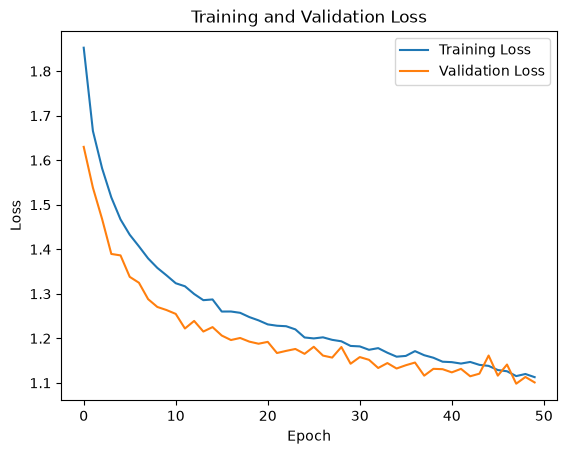

In [5]:
plt.plot(control_train_losses, label="Training Loss")
plt.plot(control_val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [6]:
#Encoding images to latent space
from AutoEncoder import AutoEncoder

weights = torch.load("oct_autoencoder_model.pth", map_location=device)
ae = AutoEncoder()
ae.load_state_dict(weights)
encoder = ae.encoder.to(device)
encoder.eval()

start_time = time.perf_counter()

train_features = []
labels_list = []

with torch.no_grad():
    for images, batch_labels in train_loader:
        images = images.to(device)
        encoded = encoder(images).flatten(1)
        train_features.append(encoded.cpu())
        labels_list.append(batch_labels)

train_features = torch.cat(train_features)
all_labels = torch.cat(labels_list)

train_encode_time = time.perf_counter() - start_time

encoded_dataset = TensorDataset(train_features, all_labels)

encoded_loader = DataLoader(
    encoded_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)


#encoding val images
start_time = time.perf_counter()

val_features = []
val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        encoded = encoder(images).flatten(1)

        val_features.append(encoded.cpu())
        val_labels.append(labels)

val_features = torch.cat(val_features)
val_labels = torch.cat(val_labels)
val_encode_time = time.perf_counter() - start_time

encoded_val_dataset = TensorDataset(val_features, val_labels)

encoded_val_loader = DataLoader(
    dataset=encoded_val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)


print(
    f"Training: {len(train_features)} samples, "
    f"Validation: {len(val_features)} samples"
)

print(
    f"Encoding time: "
    f"Train={train_encode_time:.1f}s, "
    f"Val={val_encode_time:.1f}s"
)

Training: 18400 samples, Validation: 2800 samples
Encoding time: Train=23.7s, Val=16.6s


In [7]:
#training encoded
start_time = time.perf_counter()

encoded_train_losses = []
encoded_val_losses = []

for epoch in range(num_epochs):
    encoded_classifier.train()
    total_loss = 0
    correct = 0
    total = 0

    for encoded, labels in encoded_loader:
        encoded = encoded.to(device)
        labels = labels.to(device)

        output = encoded_classifier(encoded)
        loss = criterion(output, labels)

        encoded_optimizer.zero_grad()
        loss.backward()
        encoded_optimizer.step()

        total_loss += loss.item()

        predicted = output.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = total_loss / len(train_loader)    
    accuracy = 100 * correct / total
    end_time = time.perf_counter() - start_time
    encoded_train_losses.append(epoch_train_loss)

    #val
    encoded_classifier.eval()
    
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for encoded, labels in encoded_val_loader:
            encoded, labels = encoded.to(device), labels.to(device)
            
            output = encoded_classifier(encoded)
            loss = criterion(output, labels)
            
            val_loss += loss.item()

            predicted = output.argmax(dim=1)

            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_accuracy = 100 * val_correct / val_total
    encoded_val_losses.append(epoch_val_loss)
    

    print(
        f"Epoch {epoch+1}: "
        f"Training: Loss={epoch_train_loss:.4f}, "
        f"Accuracy={accuracy:.2f}%      "
        f"Validation: Loss={epoch_val_loss:.4f}, "
        f"Val Acc={epoch_val_accuracy:.2f}%"
    )
    
end_time = time.perf_counter()

encoded_accuracy = epoch_val_accuracy
encoded_train_time = end_time - start_time

print(
    f"Results: Accuracy={encoded_accuracy:.2f}% "
    f"Training Duration={encoded_train_time:.6f} sec"
)

torch.save(encoded_classifier.state_dict(), "encoded_classifier.pth")

Epoch 1: Training: Loss=1.9607, Accuracy=24.30%      Validation: Loss=1.6802, Val Acc=36.43%
Epoch 2: Training: Loss=1.6254, Accuracy=35.82%      Validation: Loss=1.4509, Val Acc=39.43%
Epoch 3: Training: Loss=1.4622, Accuracy=38.57%      Validation: Loss=1.3414, Val Acc=41.68%
Epoch 4: Training: Loss=1.3744, Accuracy=39.84%      Validation: Loss=1.2763, Val Acc=43.68%
Epoch 5: Training: Loss=1.3192, Accuracy=41.10%      Validation: Loss=1.2326, Val Acc=45.21%
Epoch 6: Training: Loss=1.2751, Accuracy=41.76%      Validation: Loss=1.2005, Val Acc=47.25%
Epoch 7: Training: Loss=1.2411, Accuracy=43.53%      Validation: Loss=1.1749, Val Acc=47.82%
Epoch 8: Training: Loss=1.2177, Accuracy=44.19%      Validation: Loss=1.1563, Val Acc=48.54%
Epoch 9: Training: Loss=1.1967, Accuracy=45.39%      Validation: Loss=1.1407, Val Acc=49.54%
Epoch 10: Training: Loss=1.1726, Accuracy=46.29%      Validation: Loss=1.1236, Val Acc=50.71%
Epoch 11: Training: Loss=1.1572, Accuracy=47.00%      Validation: Los

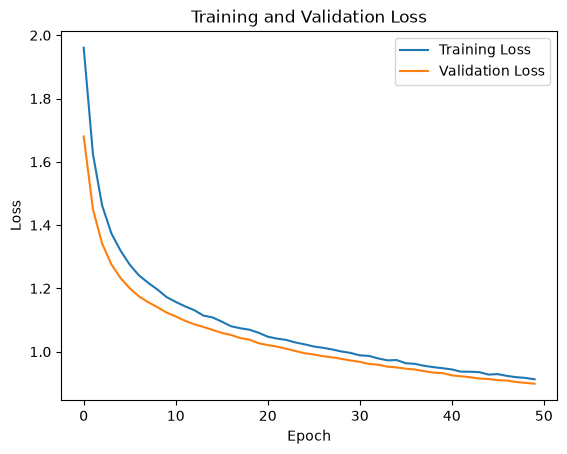

In [8]:
plt.plot(encoded_train_losses, label="Training Loss")
plt.plot(encoded_val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [9]:
#test - control

from Classifiers import ControlClassifier

test_control_classifier = ControlClassifier(8).to(device)
test_control_classifier.load_state_dict(torch.load("control_classifier.pth", map_location=device))
test_control_classifier.eval()

control_correct = 0
total = 0
control_class_correct = {c: 0 for c in range(num_classes)}
class_total = {c: 0 for c in range(num_classes)}

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        control_predict = test_control_classifier(images).argmax(1)
        control_correct += (control_predict == labels).sum().item()
        total += labels.size(0)

        for label, c_pred in zip(labels, control_predict):
            l = label.item()
            class_total[l] += 1
            control_class_correct[l] += int(l == c_pred.item())

print(f"Control test accuracy: {100 * control_correct / total:.2f}%")
print()
print(f"{'Class':<10} {'Control':>10}")
for c in range(num_classes):
    name = test_dataset.classes[c]
    c_acc = 100 * control_class_correct[c] / class_total[c]
    print(f"{name:<10} {c_acc:>9.2f}%")

Control test accuracy: 50.50%

Class         Control
AMD            99.43%
CNV            37.43%
CSR            61.14%
DME            26.00%
DR             27.43%
DRUSEN         28.29%
MH             66.57%
NORMAL         57.71%


In [10]:
#test - encoded

from Classifiers import EncodedClassifier

test_encoded_classifier = EncodedClassifier(256, 8).to(device)
test_encoded_classifier.load_state_dict(torch.load("encoded_classifier.pth", map_location=device))
test_encoded_classifier.eval()

encoded_correct = 0
total = 0
encoded_class_correct = {c: 0 for c in range(num_classes)}
class_total = {c: 0 for c in range(num_classes)}

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        encoded_predict = test_encoded_classifier(encoder(images).flatten(1)).argmax(1)
        encoded_correct += (encoded_predict == labels).sum().item()
        total += labels.size(0)

        for label, e_pred in zip(labels, encoded_predict):
            l = label.item()
            class_total[l] += 1
            encoded_class_correct[l] += int(l == e_pred.item())

print(f"Encoded test accuracy: {100 * encoded_correct / total:.2f}%")
print()
print(f"{'Class':<10} {'Encoded':>10}")
for c in range(num_classes):
    name = test_dataset.classes[c]
    e_acc = 100 * encoded_class_correct[c] / class_total[c]
    print(f"{name:<10} {e_acc:>9.2f}%")

Encoded test accuracy: 61.07%

Class         Encoded
AMD           100.00%
CNV            63.14%
CSR            72.00%
DME            52.86%
DR             53.43%
DRUSEN         31.43%
MH             63.14%
NORMAL         52.57%


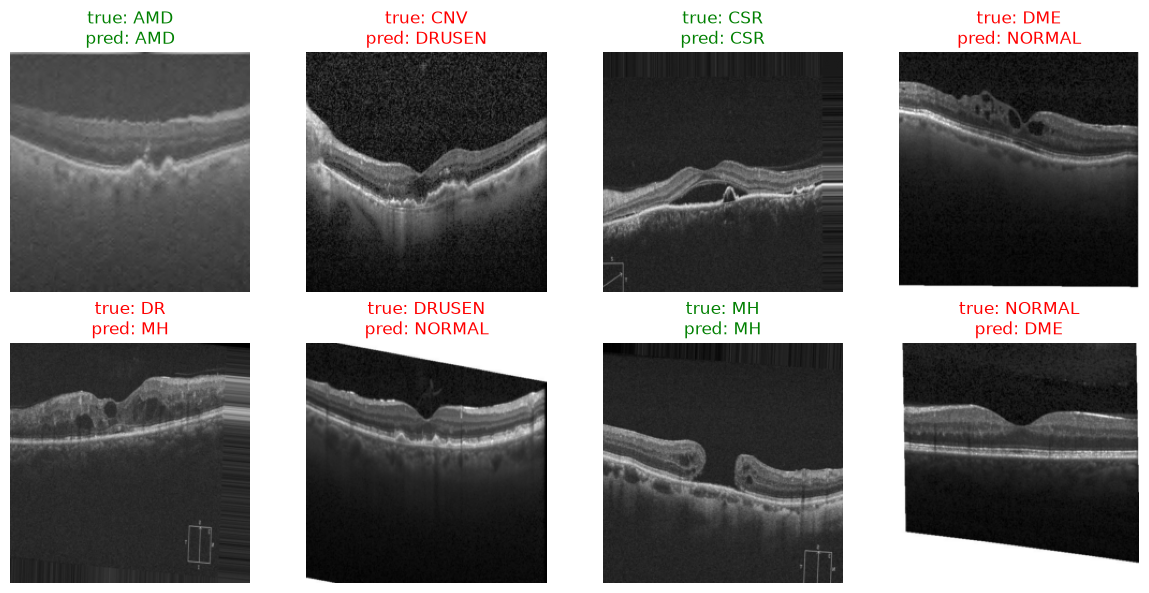

In [11]:
import matplotlib.pyplot as plt

found = {}
for images, labels in val_loader:
    for img, lab in zip(images, labels):
        c = lab.item()
        if c not in found:
            found[c] = img
    if len(found) == 8:
        break

true_ids = sorted(found)
batch = torch.stack([found[c] for c in true_ids])

control_classifier.eval()
with torch.no_grad():
    pred_ids = control_classifier(batch.to(device)).argmax(dim=1).cpu().tolist()

class_names = val_loader.dataset.classes

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, t, p in zip(axes.flat, true_ids, pred_ids):
    ax.imshow((found[t].squeeze() + 1) / 2, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"true: {class_names[t]}\npred: {class_names[p]}",
                 color='green' if t == p else 'red')
    ax.axis('off')

plt.tight_layout()
plt.show()

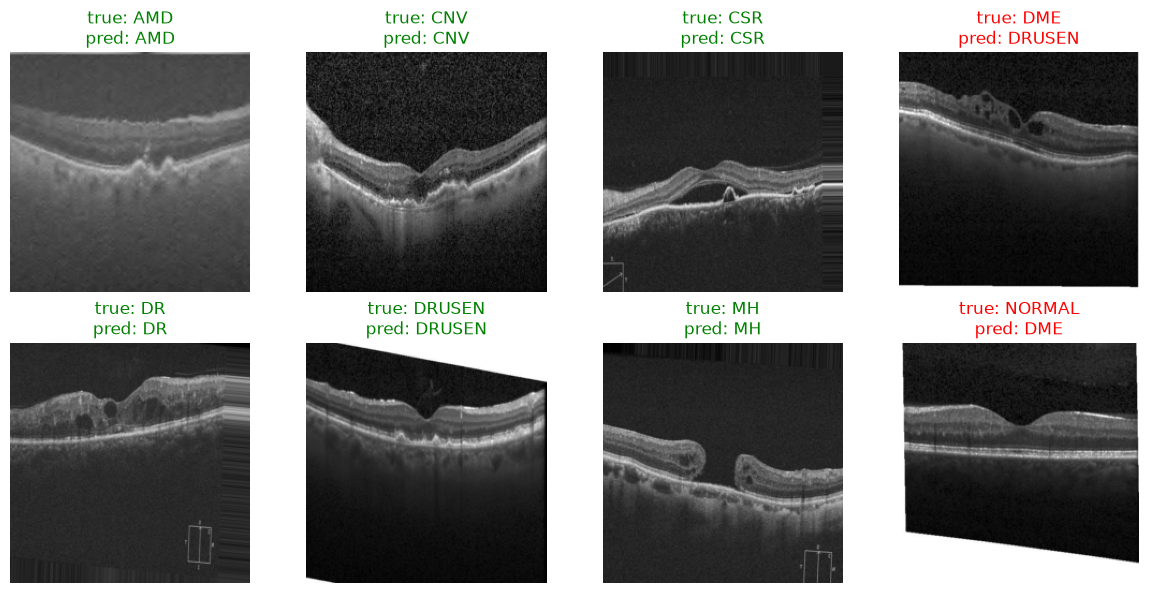

In [12]:
import matplotlib.pyplot as plt

found = {}
for images, labels in val_loader:
    for img, lab in zip(images, labels):
        c = lab.item()
        if c not in found:
            found[c] = img
    if len(found) == 8:
        break

true_ids = sorted(found)
batch = torch.stack([found[c] for c in true_ids])

encoded_classifier.eval()
with torch.no_grad():
    features = encoder(batch.to(device)).flatten(1)
    pred_ids = encoded_classifier(features).argmax(dim=1).cpu().tolist()

class_names = val_loader.dataset.classes

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, t, p in zip(axes.flat, true_ids, pred_ids):
    ax.imshow((found[t].squeeze() + 1) / 2, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"true: {class_names[t]}\npred: {class_names[p]}",
                 color='green' if t == p else 'red')
    ax.axis('off')

plt.tight_layout()
plt.show()